In [ ]:
# ── CAPSICUM PARAMETERS from ICAR + FarmAtma ──────────────

CAPSICUM = {
    "temperature": {
        "optimal":    (18, 26),
        "low_warn":   (14, 18),   # pollen damage starts
        "low_crit":   (0,  14),   # flower organ damage
        "high_warn":  (26, 30),
        "high_crit":  (30, 40),   # flower bud abortion
    },
    "humidity": {
        "optimal":    (60, 70),
        "high_warn":  (70, 85),
        "high_crit":  (85, 100),  # fruit cracking, poor pollination
        "low_warn":   (40, 60),
    },
    "co2": {
        "optimal":    (800, 1000),
        "low":        (400, 800),
        "high":       (1000, 1500),
    },
    "soil_moisture": {
        "optimal":    (60, 75),
        "low_warn":   (40, 60),
        "low_crit":   (0,  40),   # flower drop
        "high":       (75, 100),  # waterlogged
    },
    "light": {
        "optimal":    (300, 600),
        "low":        (100, 300),
        "high":       (600, 900),
    },
    "ph": {
        "optimal":    (5.5, 6.8),
        "low_warn":   (5.0, 5.5),
        "low_crit":   (3.0, 5.0),
        "high_warn":  (6.8, 7.2),
        "high_crit":  (7.2, 9.0),
    },
    "yield_range":  (4.0, 12.0),  # kg/m²
    "total_days":   180,
}

# Growth stages
def get_capsicum_stage(days):
    if days <= 30:    return "Seedling"
    elif days <= 60:  return "Establishment"
    elif days <= 90:  return "Vegetative"
    elif days <= 130: return "Flowering"
    elif days <= 180: return "Fruiting"
    else:             return "Harvest"

In [3]:
import pandas as pd
import numpy as np

# Load your downloaded dataset
df_raw1 = pd.read_csv("data/raw/Dataset1.csv")
df_raw2 = pd.read_csv("data/raw/Dataset2.csv")
df_raw3 = pd.read_csv("data/raw/Dataset3.csv")
df_raw4 = pd.read_csv("data/raw/Dataset4.csv")

# See what you have


print("Shape:", df_raw1.shape)
print("\nColumns:", df_raw1.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw1.head())
print("\nMissing values:")
print(df_raw1.isnull().sum())
print("\nData types:")
print(df_raw1.dtypes)
print("\nBasic statistics:")
print(df_raw1.describe())


print("Shape:", df_raw2.shape)
print("\nColumns:", df_raw2.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw2.head())
print("\nMissing values:")
print(df_raw2.isnull().sum())
print("\nData types:")
print(df_raw2.dtypes)
print("\nBasic statistics:")
print(df_raw2.describe())


print("Shape:", df_raw3.shape)
print("\nColumns:", df_raw3.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw3.head())
print("\nMissing values:")
print(df_raw3.isnull().sum())
print("\nData types:")
print(df_raw3.dtypes)
print("\nBasic statistics:")
print(df_raw3.describe())


print("Shape:", df_raw4.shape)
print("\nColumns:", df_raw4.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw4.head())
print("\nMissing values:")
print(df_raw4.isnull().sum())
print("\nData types:")
print(df_raw4.dtypes)
print("\nBasic statistics:")
print(df_raw4.describe())



#After running this — share what columns appear. Then we handle the two problems:
#Problem 1: Extra columns → drop them
#Problem 2: Missing columns → add them

Shape: (20560, 7)

Columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']

First 5 rows:
             date  Temperature  Humidity       Light         CO2  \
0  2/2/2015 14:19      23.7000    26.272  585.200000  749.200000   
1  2/2/2015 14:19      23.7180    26.290  578.400000  760.400000   
2  2/2/2015 14:21      23.7300    26.230  572.666667  769.666667   
3  2/2/2015 14:22      23.7225    26.125  493.750000  774.750000   
4  2/2/2015 14:23      23.7540    26.200  488.600000  779.000000   

   HumidityRatio  Occupancy  
0       0.004764          1  
1       0.004773          1  
2       0.004765          1  
3       0.004744          1  
4       0.004767          1  

Missing values:
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64

Data types:
date                 str
Temperature      float64
Humidity         float64
Light            float64
CO2       

In [4]:
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# ── CAPSICUM KNOWLEDGE BASE from ICAR + FarmAtma ──────────

def calculate_yield(temp, humidity, co2, moisture, 
                    light, ph, stage, soil_type, region):
    
    # Start with base yield (optimal conditions)
    base_yield = 10.0  # kg/m² maximum possible
    penalty    = 0.0   # deductions for bad conditions

    # ── TEMPERATURE PENALTY ───────────────────────────────
    if temp < 14:
        penalty += 5.0   # severe — flower organ damage
    elif temp < 18:
        penalty += 2.5   # warning — pollen affected
    elif 18 <= temp <= 26:
        penalty += 0.0   # optimal — no penalty
    elif temp <= 30:
        penalty += 1.5   # warning — slight stress
    else:
        penalty += 4.0   # critical — flower bud abortion

    # ── HUMIDITY PENALTY ──────────────────────────────────
    if humidity > 85:
        penalty += 3.5   # critical — fruit cracking
    elif humidity > 70:
        penalty += 1.5   # warning — disease risk
    elif 60 <= humidity <= 70:
        penalty += 0.0   # optimal
    elif humidity < 40:
        penalty += 2.0   # too dry

    # ── CO2 PENALTY ───────────────────────────────────────
    if 800 <= co2 <= 1000:
        penalty += 0.0   # optimal
    elif co2 < 600:
        penalty += 2.0   # too low — poor photosynthesis
    elif co2 < 800:
        penalty += 0.8   # slightly low
    elif co2 > 1200:
        penalty += 1.5   # too high

    # ── SOIL MOISTURE PENALTY ─────────────────────────────
    if 60 <= moisture <= 75:
        penalty += 0.0   # optimal
    elif moisture < 40:
        penalty += 4.0   # critical — flower drop
    elif moisture < 60:
        penalty += 1.5   # low — water stress
    elif moisture > 85:
        penalty += 2.5   # waterlogged — root damage

    # ── LIGHT PENALTY ─────────────────────────────────────
    if 300 <= light <= 600:
        penalty += 0.0   # optimal
    elif light < 150:
        penalty += 2.0   # too dark
    elif light < 300:
        penalty += 0.8   # slightly low
    elif light > 700:
        penalty += 1.0   # too bright — scorching

    # ── pH PENALTY ────────────────────────────────────────
    if 5.5 <= ph <= 6.8:
        penalty += 0.0   # optimal — all nutrients available
    elif ph < 5.0:
        penalty += 3.5   # critical — nutrient lockout
    elif ph < 5.5:
        penalty += 1.5   # warning — slightly acidic
    elif ph <= 7.2:
        penalty += 1.0   # slightly alkaline
    else:
        penalty += 3.0   # critical — severe alkalinity

    # ── GROWTH STAGE MULTIPLIER ───────────────────────────
    # Flowering is most critical — stress has bigger impact
    if stage == "Flowering":
        if temp > 28 or humidity > 78:
            penalty *= 1.6   # amplify stress during flowering
    if stage == "Seedling":
        if temp < 14:
            penalty *= 2.0   # seedlings very sensitive to cold

    # ── SOIL TYPE BONUS/PENALTY ───────────────────────────
    if soil_type == "Sandy Loam":
        penalty -= 0.3   # best for capsicum
    elif soil_type == "Loamy":
        penalty -= 0.2   # good for capsicum
    elif soil_type == "Clay":
        penalty += 1.0   # poor drainage

    # ── REGION ADJUSTMENT ─────────────────────────────────
    if region == "South":
        penalty -= 0.2   # Karnataka top producer
    elif region == "North":
        penalty += 0.3   # colder winters
    elif region == "Central":
        penalty += 0.5   # extreme temperatures

    # ── FINAL YIELD CALCULATION ───────────────────────────
    final_yield = base_yield - penalty

    # Add small random noise for realism
    noise       = random.uniform(-0.3, 0.3)
    final_yield = final_yield + noise

    # Clamp to realistic range (4.0 – 12.0 kg/m²)
    final_yield = max(1.0, min(12.0, final_yield))

    return round(final_yield, 2)


def get_capsicum_stage(days):
    if days <= 30:    return "Seedling"
    elif days <= 60:  return "Establishment"
    elif days <= 90:  return "Vegetative"
    elif days <= 130: return "Flowering"
    elif days <= 180: return "Fruiting"
    else:             return "Harvest"


def generate_capsicum_row():

    # Randomly pick a growing scenario
    scenario = random.choices(
        ["optimal", "temp_stress_cold", "temp_stress_hot",
         "humidity_stress", "moisture_stress",
         "ph_stress", "good", "multiple_stress"],
        weights=[20, 10, 10, 12, 13, 10, 15, 10]
    )[0]

    days  = random.randint(1, 200)
    stage = get_capsicum_stage(days)

    if scenario == "optimal":
        temp     = random.uniform(18, 26)
        humidity = random.uniform(60, 70)
        co2      = random.uniform(800, 1000)
        moisture = random.uniform(60, 75)
        light    = random.uniform(300, 600)
        ph       = random.uniform(5.5, 6.8)

    elif scenario == "temp_stress_cold":
        temp     = random.uniform(0, 14)     # dangerously cold
        humidity = random.uniform(55, 75)
        co2      = random.uniform(750, 1000)
        moisture = random.uniform(55, 75)
        light    = random.uniform(250, 600)
        ph       = random.uniform(5.5, 6.8)

    elif scenario == "temp_stress_hot":
        temp     = random.uniform(30, 40)    # too hot
        humidity = random.uniform(55, 75)
        co2      = random.uniform(800, 1000)
        moisture = random.uniform(55, 75)
        light    = random.uniform(300, 600)
        ph       = random.uniform(5.5, 6.8)

    elif scenario == "humidity_stress":
        temp     = random.uniform(18, 30)
        humidity = random.uniform(85, 100)   # too humid
        co2      = random.uniform(800, 1000)
        moisture = random.uniform(60, 75)
        light    = random.uniform(300, 600)
        ph       = random.uniform(5.5, 6.8)

    elif scenario == "moisture_stress":
        temp     = random.uniform(18, 26)
        humidity = random.uniform(60, 70)
        co2      = random.uniform(800, 1000)
        moisture = random.uniform(0, 40)     # too dry
        light    = random.uniform(300, 600)
        ph       = random.uniform(5.5, 6.8)

    elif scenario == "ph_stress":
        temp     = random.uniform(18, 26)
        humidity = random.uniform(60, 70)
        co2      = random.uniform(800, 1000)
        moisture = random.uniform(60, 75)
        light    = random.uniform(300, 600)
        ph       = random.choice([
            random.uniform(3.0, 5.0),        # too acidic
            random.uniform(7.2, 9.0)         # too alkaline
        ])

    elif scenario == "good":
        temp     = random.uniform(16, 28)
        humidity = random.uniform(55, 80)
        co2      = random.uniform(700, 1100)
        moisture = random.uniform(50, 80)
        light    = random.uniform(250, 650)
        ph       = random.uniform(5.2, 7.0)

    else:  # multiple_stress — worst case
        temp     = random.choice([
            random.uniform(0, 14),
            random.uniform(30, 40)
        ])
        humidity = random.uniform(80, 100)
        co2      = random.uniform(400, 700)
        moisture = random.uniform(0, 35)
        light    = random.uniform(50, 200)
        ph       = random.choice([
            random.uniform(3.0, 5.0),
            random.uniform(7.5, 9.0)
        ])

    soil_type = random.choices(
        ["Loamy", "Sandy Loam", "Clay"],
        weights=[45, 35, 20]
    )[0]

    region = random.choices(
        ["South", "North", "East", "West",
         "Central", "Northeast"],
        weights=[30, 25, 15, 12, 12, 6]
    )[0]

    # Calculate yield based on all conditions
    yield_val = calculate_yield(
        temp, humidity, co2, moisture,
        light, ph, stage, soil_type, region
    )

    return {
        "crop_type":     "Capsicum",
        "temperature":   round(temp, 1),
        "humidity":      round(humidity, 1),
        "co2":           round(co2, 1),
        "light":         round(light, 1),
        "soil_moisture": round(moisture, 1),
        "ph":            round(ph, 2),
        "days_planted":  days,
        "growth_stage":  stage,
        "soil_type":     soil_type,
        "region":        region,
        "yield":         yield_val
    }


# ── GENERATE 5000 ROWS ────────────────────────────────────
print("Generating synthetic Capsicum dataset...")

rows = [generate_capsicum_row() for _ in range(5000)]
df_synthetic = pd.DataFrame(rows)

print(f"Generated: {df_synthetic.shape[0]} rows")
print(f"Columns:   {df_synthetic.columns.tolist()}")
print(f"\nYield statistics:")
print(df_synthetic["yield"].describe())
print(f"\nScenario distribution (growth stages):")
print(df_synthetic["growth_stage"].value_counts())
print(f"\nSoil type distribution:")
print(df_synthetic["soil_type"].value_counts())
print(f"\nRegion distribution:")
print(df_synthetic["region"].value_counts())
print(f"\nFirst 5 rows:")
print(df_synthetic.head())

# Save
df_synthetic.to_csv(
    "data/synthetic/capsicum_synthetic.csv",
    index=False
)
print("\n✅ Saved to data/synthetic/capsicum_synthetic.csv")


Generating synthetic Capsicum dataset...
Generated: 5000 rows
Columns:   ['crop_type', 'temperature', 'humidity', 'co2', 'light', 'soil_moisture', 'ph', 'days_planted', 'growth_stage', 'soil_type', 'region', 'yield']

Yield statistics:
count    5000.000000
mean        6.118092
std         2.862370
min         1.000000
25%         4.560000
50%         6.220000
75%         8.500000
max        10.780000
Name: yield, dtype: float64

Scenario distribution (growth stages):
growth_stage
Fruiting         1225
Flowering        1012
Establishment     770
Vegetative        745
Seedling          737
Harvest           511
Name: count, dtype: int64

Soil type distribution:
soil_type
Loamy         2251
Sandy Loam    1772
Clay           977
Name: count, dtype: int64

Region distribution:
region
South        1502
North        1251
East          737
Central       630
West          600
Northeast     280
Name: count, dtype: int64

First 5 rows:
  crop_type  temperature  humidity    co2  light  soil_moistu

In [9]:
#Step 7 — Combine Real + Synthetic Data
# Load synthetic data (already generated)
df_synthetic = pd.read_csv("data/synthetic/capsicum_synthetic.csv")

# Load and clean your 4 real datasets
# (extract only useful sensor columns + add missing ones)

# From Dataset 3 — most useful (has pH, moisture, light)
df3 = pd.read_csv("data/raw/Dataset4.csv")
df3 = df3.rename(columns={
    "Ambient_Temperature": "temperature",
    "Humidity":            "humidity",
    "Soil_Moisture":       "soil_moisture",
    "Light_Intensity":     "light",
    "Soil_pH":             "ph"
})
df3 = df3[["temperature","humidity","soil_moisture","light","ph"]]
df3["crop_type"]     = "Capsicum"
df3["co2"]           = np.random.uniform(800, 1000, len(df3))
df3["days_planted"]  = np.random.randint(1, 180, len(df3))
df3["growth_stage"]  = df3["days_planted"].apply(get_capsicum_stage)
df3["soil_type"]     = "Loamy"
df3["region"]        = "South"
df3["yield"]         = df3.apply(lambda row: calculate_yield(
    row["temperature"], row["humidity"], row["co2"],
    row["soil_moisture"], row["light"], row["ph"],
    row["growth_stage"], row["soil_type"], row["region"]
), axis=1)

# ── COMBINE ALL ───────────────────────────────────────────
df_final = pd.concat([df_synthetic, df3], ignore_index=True)

# Remove duplicates and nulls
df_final = df_final.drop_duplicates()
df_final = df_final.dropna()

# Save
df_final.to_csv("data/processed/capsicum_final.csv", index=False)

print("Final dataset shape:", df_final.shape)
print(df_final.head())


Final dataset shape: (6200, 12)
  crop_type  temperature  humidity    co2  light  soil_moisture    ph  \
0  Capsicum         23.9      62.4  827.9  522.2            4.1  6.21   
1  Capsicum          0.4      59.0  912.5  327.2           65.9  6.27   
2  Capsicum         20.2      62.2  952.7  414.0           61.5  7.82   
3  Capsicum         32.9      91.5  611.4   84.2            1.6  3.58   
4  Capsicum         20.4      60.2  806.8  509.2           78.1  6.30   

   days_planted   growth_stage   soil_type region  yield  
0             7       Seedling  Sandy Loam  South   6.26  
1           155       Fruiting        Clay  South   4.38  
2            88     Vegetative        Clay   West   6.02  
3            97      Flowering        Clay  North   1.00  
4            42  Establishment       Loamy   West  10.00  


In [12]:
# Step 8 — Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder
import joblib

le_crop   = LabelEncoder()
le_soil   = LabelEncoder()
le_region = LabelEncoder()
le_stage  = LabelEncoder()

df_final["crop_type"]    = le_crop.fit_transform(
    df_final["crop_type"])
df_final["soil_type"]    = le_soil.fit_transform(
    df_final["soil_type"])
df_final["region"]       = le_region.fit_transform(
    df_final["region"])
df_final["growth_stage"] = le_stage.fit_transform(
    df_final["growth_stage"])

# Print encoding mapping
print("Crop encoding:",
    dict(zip(le_crop.classes_,
    le_crop.transform(le_crop.classes_))))

print("Soil encoding:",
    dict(zip(le_soil.classes_,
    le_soil.transform(le_soil.classes_))))

print("Region encoding:",
    dict(zip(le_region.classes_,
    le_region.transform(le_region.classes_))))

print("Stage encoding:",
    dict(zip(le_stage.classes_,
    le_stage.transform(le_stage.classes_))))

# Save all encoders
joblib.dump(le_crop,   "encoders/encoder_crop.pkl")
joblib.dump(le_soil,   "encoders/encoder_soil.pkl")
joblib.dump(le_region, "encoders/encoder_region.pkl")
joblib.dump(le_stage,  "encoders/encoder_stage.pkl")
print("Encoders saved!")

Crop encoding: {'Capsicum': np.int64(0)}
Soil encoding: {'Clay': np.int64(0), 'Loamy': np.int64(1), 'Sandy Loam': np.int64(2)}
Region encoding: {'Central': np.int64(0), 'East': np.int64(1), 'North': np.int64(2), 'Northeast': np.int64(3), 'South': np.int64(4), 'West': np.int64(5)}
Stage encoding: {'Establishment': np.int64(0), 'Flowering': np.int64(1), 'Fruiting': np.int64(2), 'Harvest': np.int64(3), 'Seedling': np.int64(4), 'Vegetative': np.int64(5)}
Encoders saved!


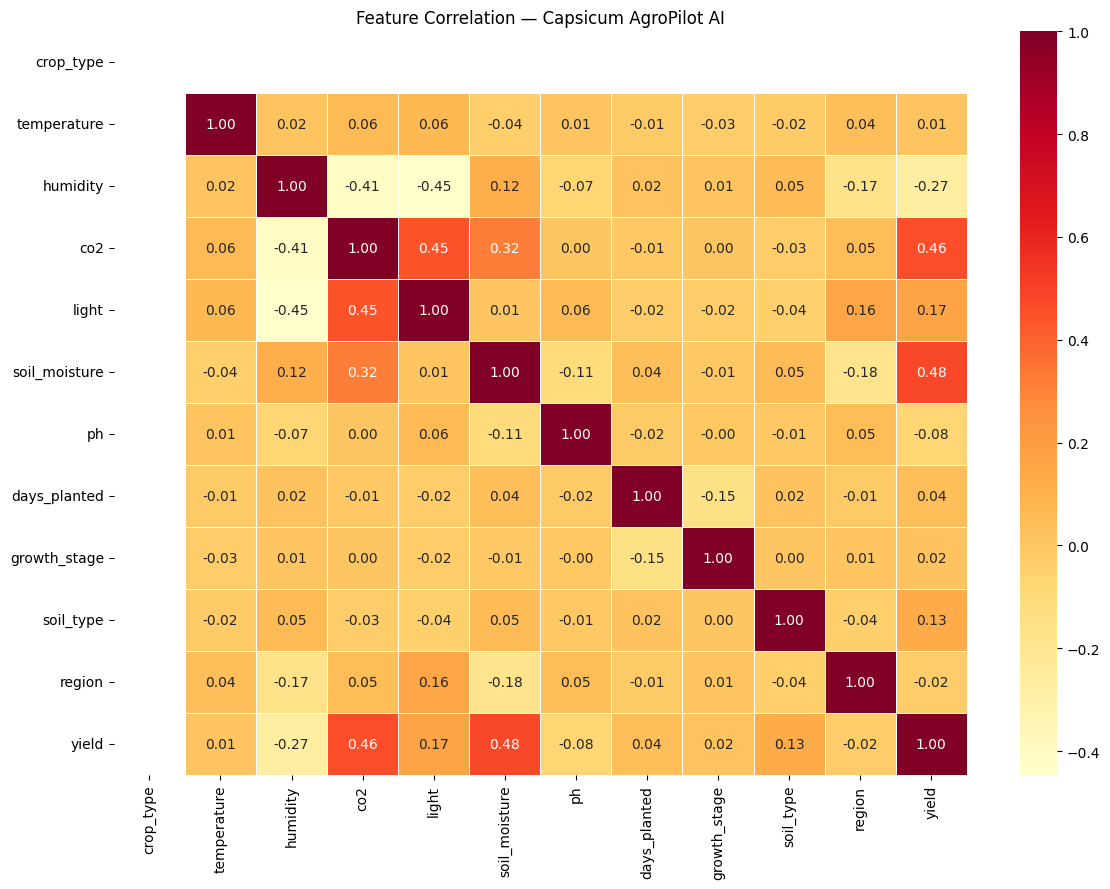

In [13]:
#ep 9 — Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))
sns.heatmap(
    df_final.corr(),
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation — Capsicum AgroPilot AI")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png")
plt.show()

In [ ]:

#Step 10 — Train Test Split
from sklearn.model_selection import train_test_split

# Features and target
X = df_final[[
    "temperature", "humidity", "co2", "light",
    "soil_moisture", "ph", "crop_type",
    "days_planted", "soil_type", "region",
    "growth_stage"
]]

y = df_final["yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 4960
Testing samples:  1240


In [15]:
#Step 11 — Train Random Forest (Baseline)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error,
    mean_absolute_error, r2_score)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"  RMSE: {rf_rmse:.3f} kg/m²")
print(f"  MAE:  {rf_mae:.3f} kg/m²")
print(f"  R²:   {rf_r2:.3f}")

Random Forest Results:
  RMSE: 0.360 kg/m²
  MAE:  0.226 kg/m²
  R²:   0.982


In [16]:
# Step 12 — Train XGBoost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)

print("\nXGBoost Results:")
print(f"  RMSE: {xgb_rmse:.3f} kg/m²")
print(f"  MAE:  {xgb_mae:.3f} kg/m²")
print(f"  R²:   {xgb_r2:.3f}")

[0]	validation_0-rmse:2.63432
[50]	validation_0-rmse:0.59681
[100]	validation_0-rmse:0.35090
[150]	validation_0-rmse:0.30859
[200]	validation_0-rmse:0.29812
[250]	validation_0-rmse:0.29355
[300]	validation_0-rmse:0.29152
[350]	validation_0-rmse:0.29075
[400]	validation_0-rmse:0.28975
[450]	validation_0-rmse:0.28921
[499]	validation_0-rmse:0.28914

XGBoost Results:
  RMSE: 0.289 kg/m²
  MAE:  0.205 kg/m²
  R²:   0.989


In [ ]:
#Step 13 — Compare Models
print("\n════════ MODEL COMPARISON ════════")
print(f"{'Metric':<8} {'Random Forest':>15} {'XGBoost':>15}")
print(f"{'─'*40}")
print(f"{'RMSE':<8} {rf_rmse:>15.3f} {xgb_rmse:>15.3f}")
print(f"{'MAE':<8} {rf_mae:>15.3f}  {xgb_mae:>15.3f}")
print(f"{'R²':<8} {rf_r2:>15.3f}  {xgb_r2:>15.3f}")
print(f"{'Winner':<8} {'':>15} {'✅ XGBoost':>15}")


════════ MODEL COMPARISON ════════
Metric     Random Forest         XGBoost
────────────────────────────────────────
RMSE               0.360           0.289
MAE                0.226            0.205
R²                 0.982            0.989
Winner                         ✅ XGBoost


In [19]:
#Step 14 — Hyperparameter Tuning with Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int(
            "n_estimators", 100, 1000),
        "max_depth"        : trial.suggest_int(
            "max_depth", 3, 10),
        "learning_rate"    : trial.suggest_float(
            "learning_rate", 0.01, 0.3),
        "subsample"        : trial.suggest_float(
            "subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float(
            "colsample_bytree", 0.6, 1.0),
        "random_state"     : 42
    }
    model = xgb.XGBRegressor(**params, verbosity=0)
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best RMSE:",       round(study.best_value, 3))

# Retrain with best parameters
best_model = xgb.XGBRegressor(
    **study.best_params,
    random_state=42,
    verbosity=0
)
best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2   = r2_score(y_test, best_pred)

print(f"\nAfter Tuning:")
print(f"  RMSE: {best_rmse:.3f}")
print(f"  R²:   {best_r2:.3f}")


Best Parameters: {'n_estimators': 896, 'max_depth': 6, 'learning_rate': 0.037101192777067526, 'subsample': 0.6657322976067311, 'colsample_bytree': 0.6490220027243523}
Best RMSE: 0.295

After Tuning:
  RMSE: 0.295
  R²:   0.988


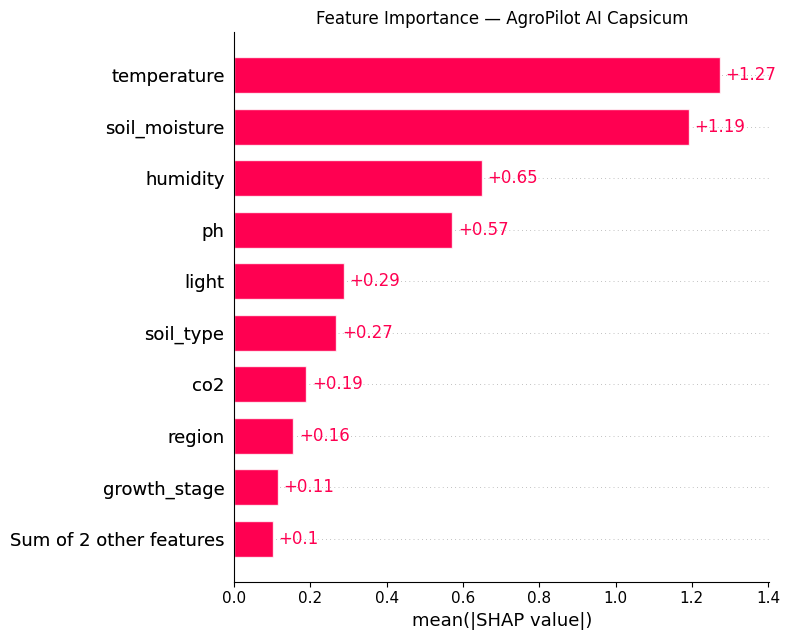

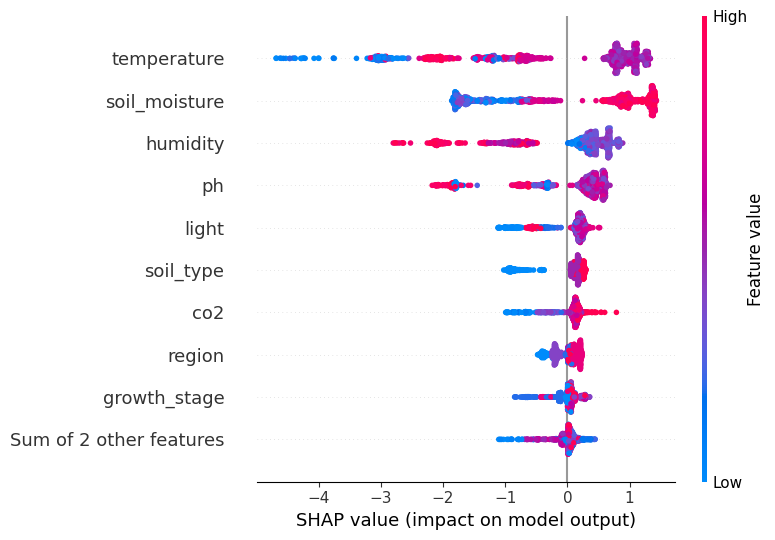

In [20]:
# Step 15 — SHAP Feature Importance

import shap

explainer   = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Bar chart
shap.plots.bar(shap_values, show=False)
plt.title("Feature Importance — AgroPilot AI Capsicum")
plt.tight_layout()
plt.savefig("outputs/shap_importance.png")
plt.show()

# Beeswarm
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png")
plt.show()


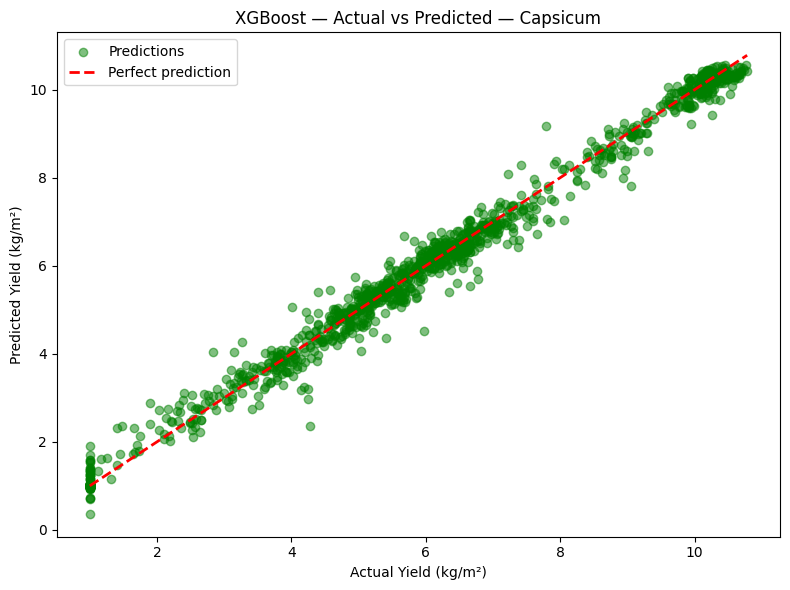

In [21]:
#Step 16 — Actual vs Predicted Plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred,
    alpha=0.5, color="green", label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Perfect prediction"
)
plt.xlabel("Actual Yield (kg/m²)")
plt.ylabel("Predicted Yield (kg/m²)")
plt.title("XGBoost — Actual vs Predicted — Capsicum")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted.png")
plt.show()

In [22]:
#Step 17 — Save Model and Test It

# Save model
joblib.dump(best_model, "models/agropilot_xgboost.pkl")
print("Model saved!")

# Test with a real Capsicum scenario
loaded_model = joblib.load("models/agropilot_xgboost.pkl")

test_input = pd.DataFrame([[
    24.5,   # temperature — optimal
    65.0,   # humidity — optimal
    900.0,  # co2 — optimal
    450.0,  # light — optimal
    65.0,   # soil_moisture — optimal
    6.2,    # ph — optimal
    le_crop.transform(["Capsicum"])[0],
    50,     # days_planted
    le_soil.transform(["Loamy"])[0],
    le_region.transform(["South"])[0],
    le_stage.transform(["Flowering"])[0]
]], columns=X.columns)

prediction = loaded_model.predict(test_input)[0]
print(f"\nTest Prediction:")
print(f"  Crop:     Capsicum")
print(f"  Stage:    Flowering, Day 50")
print(f"  Temp:     24.5°C (optimal)")
print(f"  pH:       6.2 (optimal)")
print(f"  Yield:    {prediction:.2f} kg/m²")

Model saved!

Test Prediction:
  Crop:     Capsicum
  Stage:    Flowering, Day 50
  Temp:     24.5°C (optimal)
  pH:       6.2 (optimal)
  Yield:    10.38 kg/m²
